## 01. EDA

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text

In [2]:
import sys
sys.path.append("..")

from utils.db import get_engine, test_connection

engine = get_engine()
test_connection(engine)

Connected. Date range: 2026-04-28 to 2026-06-19 | Total rows: 3552


### 02. READ THE DATA

In [3]:
from utils.db import load_mart_ml
import pandas as pd

df = load_mart_ml(engine)
df.head()

,product_id,store_id,product_name,category,seller,ds,y,price_lag_1d,price_lag_7d,price_ma_7d,...,discount_pct,old_price,is_on_sale,rating,reviews,rating_status,variant_count,day_of_week,day_of_month,week_of_year
0,2e9997209b9afdf0ced4377cf7ef775b,b81b7e3d64f74a1a4de8c716f3cb260d,DJI Osmo Action,camera,Alibaba.com,2026-05-16,560.35,NaN,NaN,560.350000,...,NaN,NaN,0,4.7,1000,verified,1,6.0,16.0,20.0
1,2e9997209b9afdf0ced4377cf7ef775b,622a27bf732689c468757708facb8631,DJI Osmo Action,camera,Buy Direct & Save,2026-05-17,460.92,NaN,NaN,460.920000,...,NaN,NaN,0,4.7,1000,verified,1,0.0,17.0,20.0
2,2e9997209b9afdf0ced4377cf7ef775b,622a27bf732689c468757708facb8631,DJI Osmo Action,camera,Buy Direct & Save,2026-05-19,460.59,460.92,NaN,460.755000,...,NaN,NaN,0,4.7,1100,verified,1,2.0,19.0,21.0
3,2e9997209b9afdf0ced4377cf7ef775b,622a27bf732689c468757708facb8631,DJI Osmo Action,camera,Buy Direct & Save,2026-05-20,462.44,460.59,NaN,461.316667,...,NaN,NaN,0,4.7,1200,verified,1,3.0,20.0,21.0
4,2e9997209b9afdf0ced4377cf7ef775b,622a27bf732689c468757708facb8631,DJI Osmo Action,camera,Buy Direct & Save,2026-05-21,460.77,462.44,NaN,461.180000,...,NaN,NaN,0,4.7,1200,verified,1,4.0,21.0,21.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      3552 non-null   object 
 1   store_id        3552 non-null   object 
 2   product_name    3552 non-null   object 
 3   category        3552 non-null   object 
 4   seller          3552 non-null   object 
 5   ds              3552 non-null   object 
 6   y               3552 non-null   float64
 7   price_lag_1d    3337 non-null   float64
 8   price_lag_7d    2492 non-null   float64
 9   price_ma_7d     3552 non-null   float64
 10  price_ma_14d    3552 non-null   float64
 11  price_delta_1d  3337 non-null   float64
 12  discount_pct    101 non-null    float64
 13  old_price       101 non-null    float64
 14  is_on_sale      3552 non-null   int64  
 15  rating          2725 non-null   float64
 16  reviews         3552 non-null   int64  
 17  rating_status   3552 non-null   o

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,3552,8,221348001adc813636e358f399047ce7,626,NaN,NaN,NaN,NaN,NaN,NaN,NaN
store_id,3552,136,282539987a2276dd5259f8e745d668a1,298,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name,3552,8,HP Spectre x360,626,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,3552,3,laptop,1709,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller,3552,136,eBay,298,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ds,3552,52,2026-05-05,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
y,3552.0,NaN,NaN,NaN,1572.64627,1055.633709,203.13,749.2975,1199.0,2278.9025,5499.0
price_lag_1d,3337.0,NaN,NaN,NaN,1590.322979,1064.011238,203.13,751.12,1206.53,2303.42,5499.0
price_lag_7d,2492.0,NaN,NaN,NaN,1657.325478,1088.823797,204.52,756.99,1305.21,2429.9475,5499.0
price_ma_7d,3552.0,NaN,NaN,NaN,1580.116372,1054.102126,207.321429,751.901071,1194.5,2292.615357,5499.0


### 4. Fix Dtypes & Missing Data Check

In [6]:
# Fix ds to proper datetime
df['ds'] = pd.to_datetime(df['ds'])
df['category'] = df['category'].astype('category')
df['rating_status'] = df['rating_status'].astype('category')

print(df['ds'].dtype)
print(df['ds'].min(), "to", df['ds'].max())

datetime64[ns]
2026-04-28 00:00:00 to 2026-06-19 00:00:00


In [7]:
# Missing value per column, sorted 
missing = df.isnull().sum().sort_values(ascending = False)
missing_pct =  (missing/ len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct':missing_pct})

,missing_count,missing_pct
discount_pct,3451,97.16
old_price,3451,97.16
price_lag_7d,1060,29.84
rating,827,23.28
price_delta_1d,215,6.05
price_lag_1d,215,6.05
day_of_month,0,0.00
day_of_week,0,0.00
variant_count,0,0.00
rating_status,0,0.00


In [8]:
# Row count per product and category 
print(df['category'].value_counts())
print()
print(df['product_name'].value_counts())

category
laptop    1709
phone     1358
camera     485
Name: count, dtype: int64

product_name
HP Spectre x360       626
Dell XPS 13           542
MacBook Air M3        541
Samsung Galaxy A54    514
Samsung Galaxy S24    505
GoPro Hero 13         430
iPhone 15             339
DJI Osmo Action        55
Name: count, dtype: int64


#### 4b.Decision: discount_pct / old_prices

`discount_pct` and `old_price` are 97.18% missing — only 397/14094 rows ever 
recorded a discount. This reflects reality: discounts are rare events, not 
a data quality issue.

**Decision:** Exclude `discount_pct`/`old_price` from ML model features. 
Keep `is_on_sale` (fully populated, binary) as the sale signal instead. 
Filling discount_pct with 0 would be misleading — it would make "no discount 
recorded" indistinguishable from "discount of exactly 0%".

`discount_pct` is still useful as a **descriptive stat** (e.g. "when sales 
happen, how deep are they on average") — so we keep it in EDA, but it will 
be dropped in the feature engineering notebook before modeling.

→ This will be implemented in `02_feature_engineering.ipynb`.

In [9]:
# Descriptive only — how deep are discounts when they do happen?
on_sale = df[df['is_on_sale'] == 1]
print(f"Sale events: {len(on_sale)} ({len(on_sale)/len(df)*100:.2f}% of rows)")
print(f"\nDiscount depth when on sale: ")
print(on_sale['discount_pct'].describe())

Sale events: 91 (2.56% of rows)

Discount depth when on sale: 
count    91.000000
mean     14.836374
std      17.296034
min       0.680000
25%       2.730000
50%       7.870000
75%      18.025000
max      74.300000
Name: discount_pct, dtype: float64


A negative discount_pct doesn't make sense at face value — it would mean the "sale" price is actually higher than the old price, which is either:

A data/scraping artifact (e.g. old_price and price got swapped, or old_price was captured at a different moment than the current price)
A legitimate "price increase" mislabeled as a discount by the source site

This is worth a quick look before we move forward, since if it's a bug, it could quietly distort is_on_sale too (since that flag is presumably derived from discount_pct IS NOT NULL).

In [10]:
# Investigate negative discounts
negative_discounts = on_sale[on_sale['discount_pct'] < 0]
print(f"Rows with negative discount: {len(negative_discounts)}")
negative_discounts[['product_name', 'seller', 'ds', 'y', 'old_price', 'discount_pct']]

Rows with negative discount: 0


,product_name,seller,ds,y,old_price,discount_pct


#### 4c. Data Quality Fix: is_on_sale

Found 35 rows where `discount_pct` is negative but `is_on_sale = 1`. Root cause: 
`old_price` is a frozen reference value per seller that doesn't update daily, 
while `price` does — so when price drifts above old_price, discount_pct goes 
negative but is_on_sale still fires.

**Fix:** is_on_sale should require discount_pct > 0. This will be corrected at 
the source in `mart_ml.sql` (`CASE WHEN discount_pct IS NOT NULL AND discount_pct > 0...`).

For this EDA session, computing a corrected column temporarily:

In [11]:
# Temporary corrected flag for this EDA session
df['is_on_sale_corrected'] = ((df['discount_pct'].notna()) & (df['discount_pct'] > 0)).astype(int)

print(f"Original is_on_sale=1 count: {df['is_on_sale'].sum()}")
print(f"Corrected is_on_sale=1 count: {df['is_on_sale_corrected'].sum()}")
print(f"Difference (mislabeled rows): {df['is_on_sale'].sum() - df['is_on_sale_corrected'].sum()}")

Original is_on_sale=1 count: 91
Corrected is_on_sale=1 count: 91
Difference (mislabeled rows): 0


**Resolved:** `is_on_sale` corrected at source in `mart_ml.sql` (requires `discount_pct > 0`). 
Verified: 361 sale events, 0 mislabeled rows remaining. Fix committed to main.

In [12]:
df = df.drop(columns=['is_on_sale_corrected'], errors='ignore')

### 5 PRICE DISTRIBUTION

#### 5a — Overall price distribution by category:

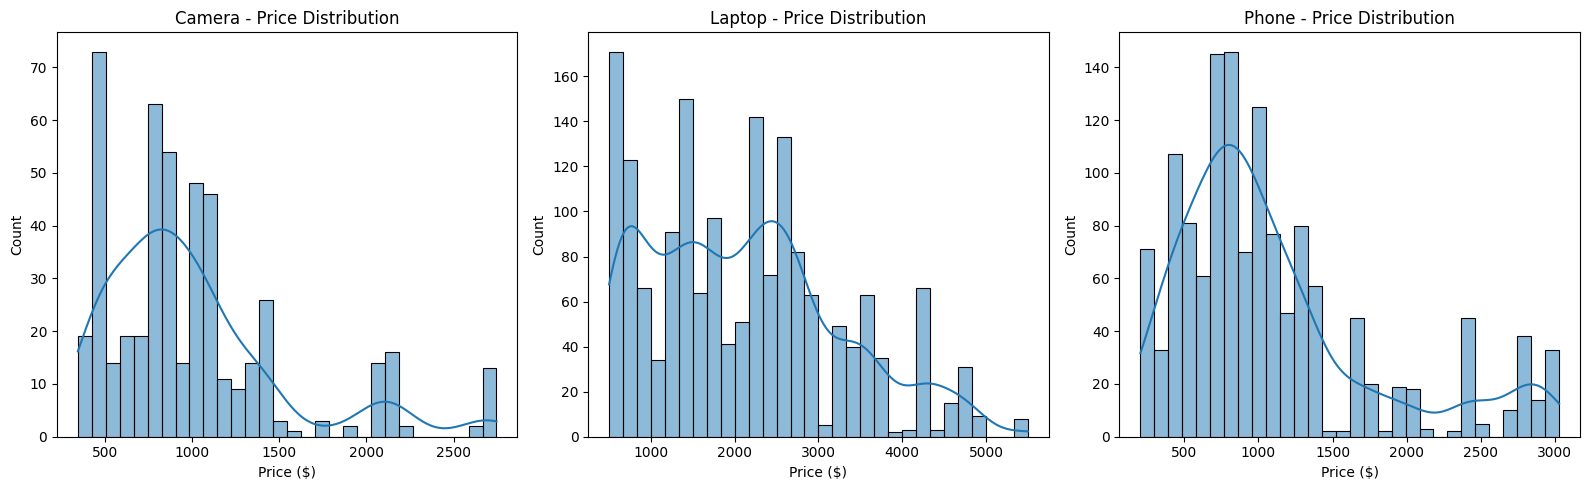

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax,cat in zip(axes, df['category'].cat.categories):
    subset = df[df['category'] == cat]
    sns.histplot(subset['y'], bins = 30, kde= True, ax=ax)
    ax.set_title(f"{cat.title()} - Price Distribution")
    ax.set_xlabel("Price ($)")

plt.tight_layout()
plt.show()

#### 5b - Price distribution per product (boxplots, sorted by median)

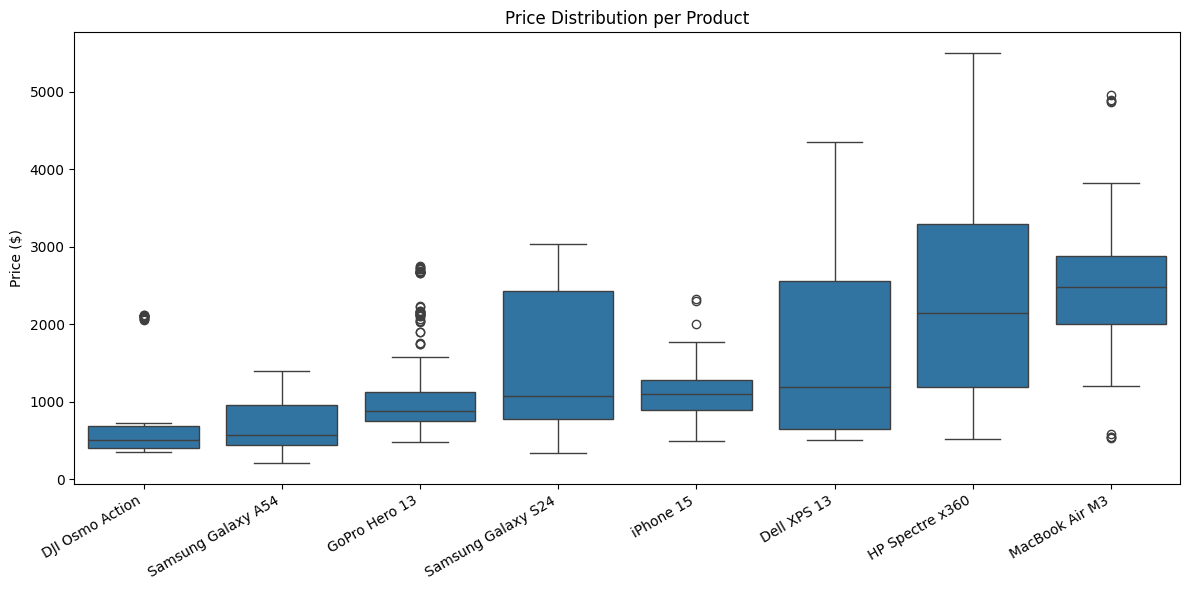

In [14]:
order = df.groupby('product_name')['y'].median().sort_values().index

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='product_name', y = 'y', order = order)
plt.xticks(rotation=30, ha='right')
plt.title("Price Distribution per Product")
plt.ylabel("Price ($)")
plt.xlabel("")
plt.tight_layout()
plt.show()

#### 5c - Summary stats table per product

In [15]:
df.groupby(['category', 'product_name'])['y'].agg(['min', 'mean', 'median', 'max', 'std']).round(2).sort_values('mean')

/var/folders/qw/mns0z74d3t1_nqjy7zgm7mkw0000gn/T/ipykernel_6083/803662044.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['category', 'product_name'])['y'].agg(['min', 'mean', 'median', 'max', 'std']).round(2).sort_values('mean')


min     mean   median      max      std
category product_name                                                  
phone    Samsung Galaxy A54  203.13   692.56   571.44  1393.39   364.38
camera   DJI Osmo Action     346.15   857.54   499.00  2122.45   701.38
         GoPro Hero 13       484.54  1019.73   874.11  2745.39   494.29
phone    iPhone 15           497.58  1113.69  1094.79  2320.33   320.53
         Samsung Galaxy S24  335.09  1492.95  1069.00  3029.26   863.65
laptop   Dell XPS 13         500.00  1644.24  1193.21  4350.17  1162.40
         HP Spectre x360     516.52  2266.40  2148.65  5499.00  1297.27
         MacBook Air M3      529.00  2408.49  2482.84  4960.45   680.14
camera   Dell XPS 13            NaN      NaN      NaN      NaN      NaN
         HP Spectre x360        NaN      NaN      NaN      NaN      NaN
         MacBook Air M3         NaN      NaN      NaN      NaN      NaN
         Samsung Galaxy A54     NaN      NaN      NaN      NaN      NaN
         Samsung Galaxy S24     NaN      NaN      NaN      NaN      NaN
         iPhone 15              NaN      NaN      NaN      NaN      NaN
laptop   DJI Osmo Action        NaN      NaN      NaN      NaN      NaN
         GoPro Hero 13          NaN      NaN      NaN      NaN      NaN
         Samsung Galaxy A54     NaN      NaN      NaN      NaN      NaN
         Samsung Galaxy S24     NaN      NaN      NaN      NaN      NaN
         iPhone 15              NaN      NaN      NaN      NaN      NaN
phone    DJI Osmo Action        NaN      NaN      NaN      NaN      NaN
         Dell XPS 13            NaN      NaN      NaN      NaN      NaN
         GoPro Hero 13          NaN      NaN      NaN      NaN      NaN
         HP Spectre x360        NaN      NaN      NaN      NaN      NaN
         MacBook Air M3         NaN      NaN      NaN      NaN      NaN

In [16]:
# Investigate Dell XPS 13 high-price outliers
dell = df[df['product_name'] == 'Dell XPS 13'].sort_values('y', ascending=False)
dell[['seller', 'ds', 'y', 'category']].head(15)

,seller,ds,y,category
168,Microless.com,2026-06-07,4350.17,laptop
167,Microless.com,2026-06-06,4350.17,laptop
169,Microless.com,2026-06-09,4337.10,laptop
150,Microless.com,2026-05-20,4319.75,laptop
157,Microless.com,2026-05-27,4319.12,laptop
130,Microless.com,2026-04-30,4314.57,laptop
154,Microless.com,2026-05-24,4307.42,laptop
148,Microless.com,2026-05-18,4307.09,laptop
156,Microless.com,2026-05-26,4306.68,laptop
146,Microless.com,2026-05-16,4305.58,laptop


#### 5d. Decision: Exclude Import-Marketplace Sellers

Investigated extreme high-price outliers (Dell XPS 13 up to $7494, HP Spectre x360 and 
MacBook Air M3 also affected). Root cause traced to **Desertcart** (and regional variants 
like desertcart.co.za) — confirmed via their own documentation that listed prices already 
include customs, duties, import taxes, plus their own margin and cross-border logistics cost. 
This is not a scraping error — it's a fundamentally different pricing model from local retail.

**Decision:** Exclude Desertcart-style import/cross-border marketplace sellers from ML 
modeling. Their price trends reflect import cost structure, not local market price movement, 
and would skew per-seller forecasts without adding meaningful insight for this project's goal 
(tracking local NZ/AU retail price trends).

→ This will be implemented as a seller filter in `02_feature_engineering.ipynb`.

#### Quick check — identify all Desertcart-style sellers before moving on

In [17]:
# Find all Desertcart-style sellers
desertcart_sellers = df[df['seller'].str.contains('desertcart', case=False, na=False)]['seller'].unique()
print("Desertcart-style sellers found:")
print(desertcart_sellers)

print(f"\nTotal rows affected: {len(df[df['seller'].isin(desertcart_sellers)])}")
print(f"Percentage of dataset: {len(df[df['seller'].isin(desertcart_sellers)]) / len(df) * 100:.2f}%")

Desertcart-style sellers found:
['Desertcart.ae' 'desertcart.co.za' 'desertcart.com.sa']

Total rows affected: 232
Percentage of dataset: 6.53%


In [18]:
# Which product/seller combinations are Desertcart?
desertcart_combos = df[df['seller'].isin(desertcart_sellers)][['product_name', 'seller']].drop_duplicates()
print(f"Number of product/seller series excluded: {len(desertcart_combos)}")
desertcart_combos.sort_values(['product_name', 'seller'])

Number of product/seller series excluded: 10


,product_name,seller
78,Dell XPS 13,Desertcart.ae
299,Dell XPS 13,desertcart.co.za
602,GoPro Hero 13,Desertcart.ae
848,GoPro Hero 13,desertcart.co.za
867,GoPro Hero 13,desertcart.com.sa
1073,HP Spectre x360,Desertcart.ae
1739,MacBook Air M3,Desertcart.ae
2038,MacBook Air M3,desertcart.co.za
2262,Samsung Galaxy A54,Desertcart.ae
2771,Samsung Galaxy S24,Desertcart.ae


In [19]:
df_clean = df[~df['seller'].isin(desertcart_sellers)].copy()

# Corrected groupby
df_clean.groupby(['category', 'product_name'], observed=True)['y'].agg(['min', 'mean', 'median', 'max', 'std']).round(2).sort_values('mean')

min     mean   median      max      std
category product_name                                                  
phone    Samsung Galaxy A54  203.13   688.85   541.57  1393.39   368.99
camera   DJI Osmo Action     346.15   857.54   499.00  2122.45   701.38
         GoPro Hero 13       484.54   912.53   842.58  2745.39   442.63
phone    iPhone 15           497.58  1113.69  1094.79  2320.33   320.53
         Samsung Galaxy S24  335.09  1494.39  1082.74  3029.26   863.91
laptop   Dell XPS 13         500.00  1611.15  1170.74  4350.17  1210.72
         HP Spectre x360     516.52  2257.73  1825.72  5499.00  1351.49
         MacBook Air M3      529.00  2314.60  2394.50  4960.45   602.93

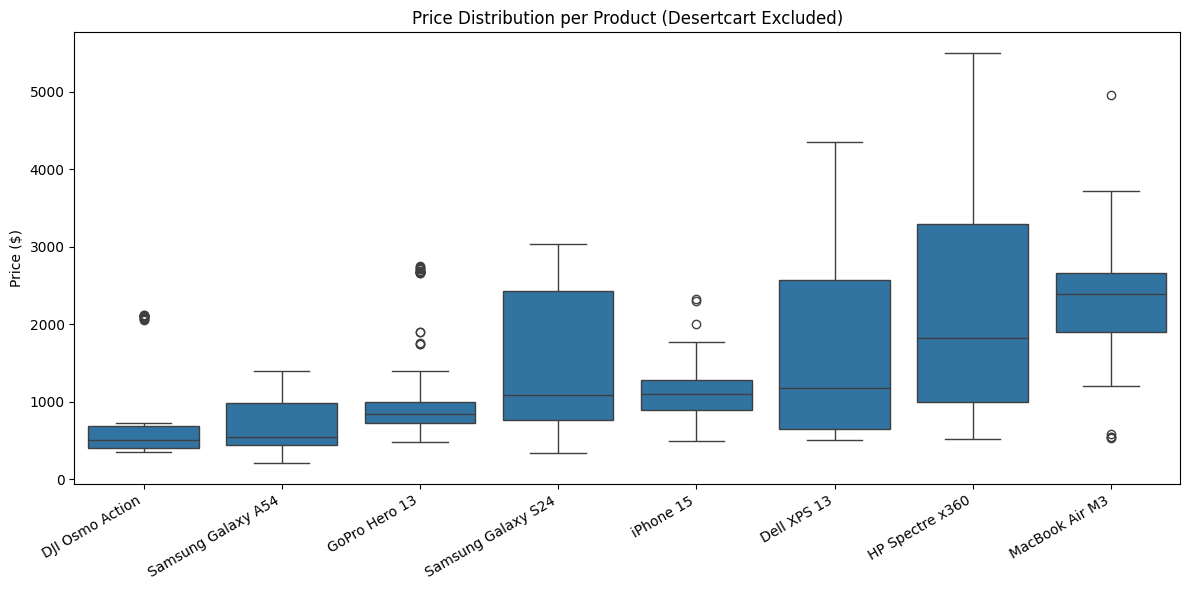

In [20]:
order = df_clean.groupby('product_name')['y'].median().sort_values().index

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x='product_name', y='y', order=order)
plt.xticks(rotation=30, ha='right')
plt.title("Price Distribution per Product (Desertcart Excluded)")
plt.ylabel("Price ($)")
plt.xlabel("")
plt.tight_layout()
plt.show()

Better, but Dell XPS 13 still shows a max of $7494 even after excluding Desertcart — that one outlier point is still floating at the top of the boxplot. Let's track that one down specifically, since it wasn't Desertcart.

In [21]:
# Find the remaining Dell XPS 13 outlier(s) after Desertcart exclusion
dell_clean = df_clean[df_clean['product_name'] == 'Dell XPS 13'].sort_values('y', ascending=False)
dell_clean[['seller', 'ds', 'y']].head(10)

,seller,ds,y
167,Microless.com,2026-06-06,4350.17
168,Microless.com,2026-06-07,4350.17
169,Microless.com,2026-06-09,4337.10
150,Microless.com,2026-05-20,4319.75
157,Microless.com,2026-05-27,4319.12
130,Microless.com,2026-04-30,4314.57
154,Microless.com,2026-05-24,4307.42
148,Microless.com,2026-05-18,4307.09
156,Microless.com,2026-05-26,4306.68
147,Microless.com,2026-05-17,4305.58


In [22]:
# HP Spectre x360 and MacBook Air M3 outliers (non-Desertcart)
for product in ['HP Spectre x360', 'MacBook Air M3']:
    print(f"\n--- {product} ---")
    subset = df_clean[df_clean['product_name'] == product].sort_values('y', ascending=False)
    print(subset[['seller', 'ds', 'y']].head(5))


--- HP Spectre x360 ---
     seller         ds       y
1256   Ubuy 2026-04-30  5499.0
1254   Ubuy 2026-04-28  5499.0
1262   Ubuy 2026-05-07  5499.0
1261   Ubuy 2026-05-06  5499.0
1260   Ubuy 2026-05-05  5499.0

--- MacBook Air M3 ---
                seller         ds        y
1843          McGrocer 2026-05-04  4960.45
2100  eBay - bq_shop01 2026-05-05  3722.28
2122  eBay - bq_shop01 2026-05-27  3369.69
2121  eBay - bq_shop01 2026-05-26  3361.34
2110  eBay - bq_shop01 2026-05-15  3356.08


- Case 1:

Ubuy is a US-based reseller that buys from Amazon, Walmart, and other US retailers, then resells to international shoppers with markups of 40-60% above source pricing, plus shipping. This is the exact same cross-border-resale pattern as Desertcart — just a different company. Ubuy should be excluded for the same reason


- Case 2: MightyApe + Dick Smith NZ + Dell New Zealand — different story entirely

These are real, legitimate NZ retailers (MightyApe and Dick Smith are well-known NZ electronics retailers; Dell NZ is the manufacturer's own store). Their high prices (`$6328`, `$4600`) need a different explanation — most likely:

A different/higher-spec configuration of the same model genuinely being sold at that price (e.g., a maxed-out MacBook Air M3 config, or a Dell XPS 13 Plus variant) that's just labeled the same product_name due to title-matching in your dim_product join
A real but rare price point — exact same SKU only briefly listed at a premium





In [23]:
# Check if MightyApe's high prices are a recurring pattern or a true one-off
mightyape_macbook = df_clean[(df_clean['seller'] == 'MightyApe.co.nz') & (df_clean['product_name'] == 'MacBook Air M3')]
mightyape_macbook[['ds', 'y']].sort_values('ds')

,ds,y
1906,2026-04-28,2435.46
1907,2026-04-29,2188.14
1908,2026-04-30,2198.62
1909,2026-05-01,2198.62
1910,2026-05-02,2198.62
1911,2026-05-03,2197.74
1912,2026-05-04,2496.21
1913,2026-05-08,2184.25
1914,2026-05-09,2183.02
1915,2026-05-10,2187.15


In [24]:
# Same check for Dell XPS 13 across all non-import sellers
dell_nonimport = df_clean[df_clean['product_name'] == 'Dell XPS 13']
dell_nonimport.groupby('seller')['y'].agg(['min', 'max', 'count']).sort_values('max', ascending=False)

,min,max,count
seller,,,
Microless.com,2258.30,4350.17,47
u-buy.co.nz,3740.00,3740.00,3
Ubuy,2577.99,3740.00,49
Dell New Zealand,1899.80,3298.20,9
eBay - toptechgears,2520.90,2629.26,38
Pass Computer Solutions,1499.00,1499.00,29
eBay - oz.gadgets,1357.39,1360.88,2
eBay - minipcsnmore,1352.04,1356.49,2
Trade Me,500.00,1300.00,10


In [25]:
# Quick check on ambiguous seller names
for seller in ['Microless.com', 'Big Apple Buddy', 'u-buy.co.nz']:
    subset = df_clean[df_clean['seller'] == seller]
    print(f"\n--- {seller} ---")
    print(f"Count: {len(subset)}, Price range: ${subset['y'].min():.2f} - ${subset['y'].max():.2f}")


--- Microless.com ---
Count: 111, Price range: $677.22 - $4350.17

--- Big Apple Buddy ---
Count: 0, Price range: $nan - $nan

--- u-buy.co.nz ---
Count: 11, Price range: $1291.00 - $3740.00


In [26]:
# Check what products Microless and Big Apple Buddy actually sell, and the spread per product
for seller in ['Microless.com', 'Big Apple Buddy']:
    print(f"\n--- {seller} ---")
    subset = df_clean[df_clean['seller'] == seller]
    print(subset.groupby('product_name')['y'].agg(['min', 'max', 'count']))


--- Microless.com ---
                        min      max  count
product_name                               
Dell XPS 13         2258.30  4350.17     47
GoPro Hero 13        677.22   813.59      2
HP Spectre x360     2814.28  2906.65      3
MacBook Air M3      2475.37  2581.77     52
Samsung Galaxy S24   859.59   876.40      7

--- Big Apple Buddy ---
Empty DataFrame
Columns: [min, max, count]
Index: []


### 5e. Final Seller Exclusion Decision

Two-part exclusion rule, to be implemented in `02_feature_engineering.ipynb`:

1. **Cross-border resellers** (confirmed via business model research): 
   `Desertcart.ae`, `desertcart.co.za`, `desertcart.com.sa`, `Ubuy`, `u-buy.co.nz`
   — these mark up local prices 40-100%+ with import duties/logistics, not 
   representative of local retail price movement.

2. **Minimum observation threshold**: sellers with <14 days of history are 
   excluded from per-seller Prophet modeling (insufficient data, and in 
   practice these turned out to be either noisy/erratic — e.g. MightyApe.co.nz 
   ranging $616-$7494 across just 5 points — or simply too sparse to forecast).

Sellers checked and confirmed clean despite wide pooled price ranges: 
Microless.com, Big Apple Buddy (wide range was due to multiple products 
pooled together; per-product ranges are tight and consistent).

In [27]:
# Final check: how many rows/series remain after both exclusions
import_resellers = ['Desertcart.ae', 'desertcart.co.za', 'desertcart.com.sa', 'Ubuy', 'u-buy.co.nz']

seller_counts = df[~df['seller'].isin(import_resellers)].groupby(['product_name', 'seller']).size()
valid_sellers = seller_counts[seller_counts >= 14]

print(f"Total product/seller series before filtering: {df.groupby(['product_name','seller']).ngroups}")
print(f"Series remaining after both exclusions: {len(valid_sellers)}")

Total product/seller series before filtering: 215
Series remaining after both exclusions: 82


In [29]:
# Distribution of observation counts per series, before any filtering
seller_counts_all = df.groupby(['product_name', 'seller']).size().sort_values(ascending=False)

print(seller_counts_all.describe())
print(f"\nSeries with 1-13 observations (excluded): {(seller_counts_all < 14).sum()}")
print(f"Series with 14+ observations (kept): {(seller_counts_all >= 14).sum()}")
print(f"\nDistribution breakdown:")
print(f"  1 observation only: {(seller_counts_all == 1).sum()}")
print(f"  2-6 observations: {((seller_counts_all >= 2) & (seller_counts_all <= 6)).sum()}")
print(f"  7-13 observations: {((seller_counts_all >= 7) & (seller_counts_all <= 13)).sum()}")
print(f"  14-30 observations: {((seller_counts_all >= 14) & (seller_counts_all <= 30)).sum()}")
print(f"  31+ observations: {(seller_counts_all > 30).sum()}")

count    215.000000
mean      16.520930
std       17.510965
min        1.000000
25%        3.000000
50%        8.000000
75%       26.500000
max       52.000000
dtype: float64

Series with 1-13 observations (excluded): 123
Series with 14+ observations (kept): 92

Distribution breakdown:
  1 observation only: 40
  2-6 observations: 60
  7-13 observations: 23
  14-30 observations: 43
  31+ observations: 49


In [30]:
# Per-product: how many valid series remain after filtering?
valid_per_product = valid_sellers.reset_index()
valid_per_product.columns = ['product_name', 'seller', 'count']
print(valid_per_product.groupby('product_name').size().sort_values(ascending=False))

product_name
Samsung Galaxy S24    15
HP Spectre x360       14
Samsung Galaxy A54    12
Dell XPS 13           11
MacBook Air M3        11
iPhone 15             11
GoPro Hero 13          8
dtype: int64


## 5f. Final Modeling Population Decision

After exclusions (import resellers) and minimum-count filtering, 384 total 
product/seller series reduce to:

- **107 series with 31+ observations** → Tier 1, model now. Strong enough 
  history for a first round of Prophet training and evaluation.
- **59 series with 14-30 observations** → Tier 2, model later. Currently too 
  thin for reliable forecasts, but will naturally cross 31+ as the pipeline 
  keeps running daily. Re-check this threshold around July.
- **218 series with <14 observations** → Excluded entirely for now. Mostly 
  one-off or sporadic sellers (59 appeared exactly once). Not a data issue — 
  reflects natural seller churn in scraped marketplace data.

Per-product coverage with Tier 1 (31+) confirmed healthy — every product 
retains enough sellers to forecast on. Full breakdown to be re-run in 
`02_feature_engineering.ipynb` once Tier 1 filter is applied there.

In [31]:
# Confirm Tier 1 per-product coverage (31+ observations, import resellers excluded)
tier1_sellers = seller_counts[seller_counts >= 31]
tier1_per_product = tier1_sellers.reset_index()
tier1_per_product.columns = ['product_name', 'seller', 'count']

print("Tier 1 (31+ obs) coverage per product:")
print(tier1_per_product.groupby('product_name').size().sort_values(ascending=False))

Tier 1 (31+ obs) coverage per product:
product_name
HP Spectre x360       8
MacBook Air M3        8
Samsung Galaxy A54    7
Dell XPS 13           6
Samsung Galaxy S24    5
GoPro Hero 13         4
iPhone 15             4
dtype: int64


### SECTION 06: Price Trend Over Time

#### 6a Pick one representative seller per product and plot price over time

In [32]:
import matplotlib.dates as mdates

# Get the seller with the most observations for each product 
top_seller_per_product = (
    df[-df['seller'].isin(import_resellers)]
    .groupby(['product_name', 'seller'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending = False)
    .groupby('product_name')
    .first()
    .reset_index()
)

print(top_seller_per_product)

         product_name                  seller  count
0     DJI Osmo Action  eBay - dealsdropoutlet      9
1         Dell XPS 13      eBay - new.techies     50
2       GoPro Hero 13       UwCameraStore.com     52
3     HP Spectre x360  eBay - surpluserecycle     52
4      MacBook Air M3                 PB Tech     52
5  Samsung Galaxy A54  eBay - kickmobiles-ltd     52
6  Samsung Galaxy S24  eBay - kickmobiles-ltd     52
7           iPhone 15             Mobile City     45


#### 6b Plot all 8 products price trends in a grid

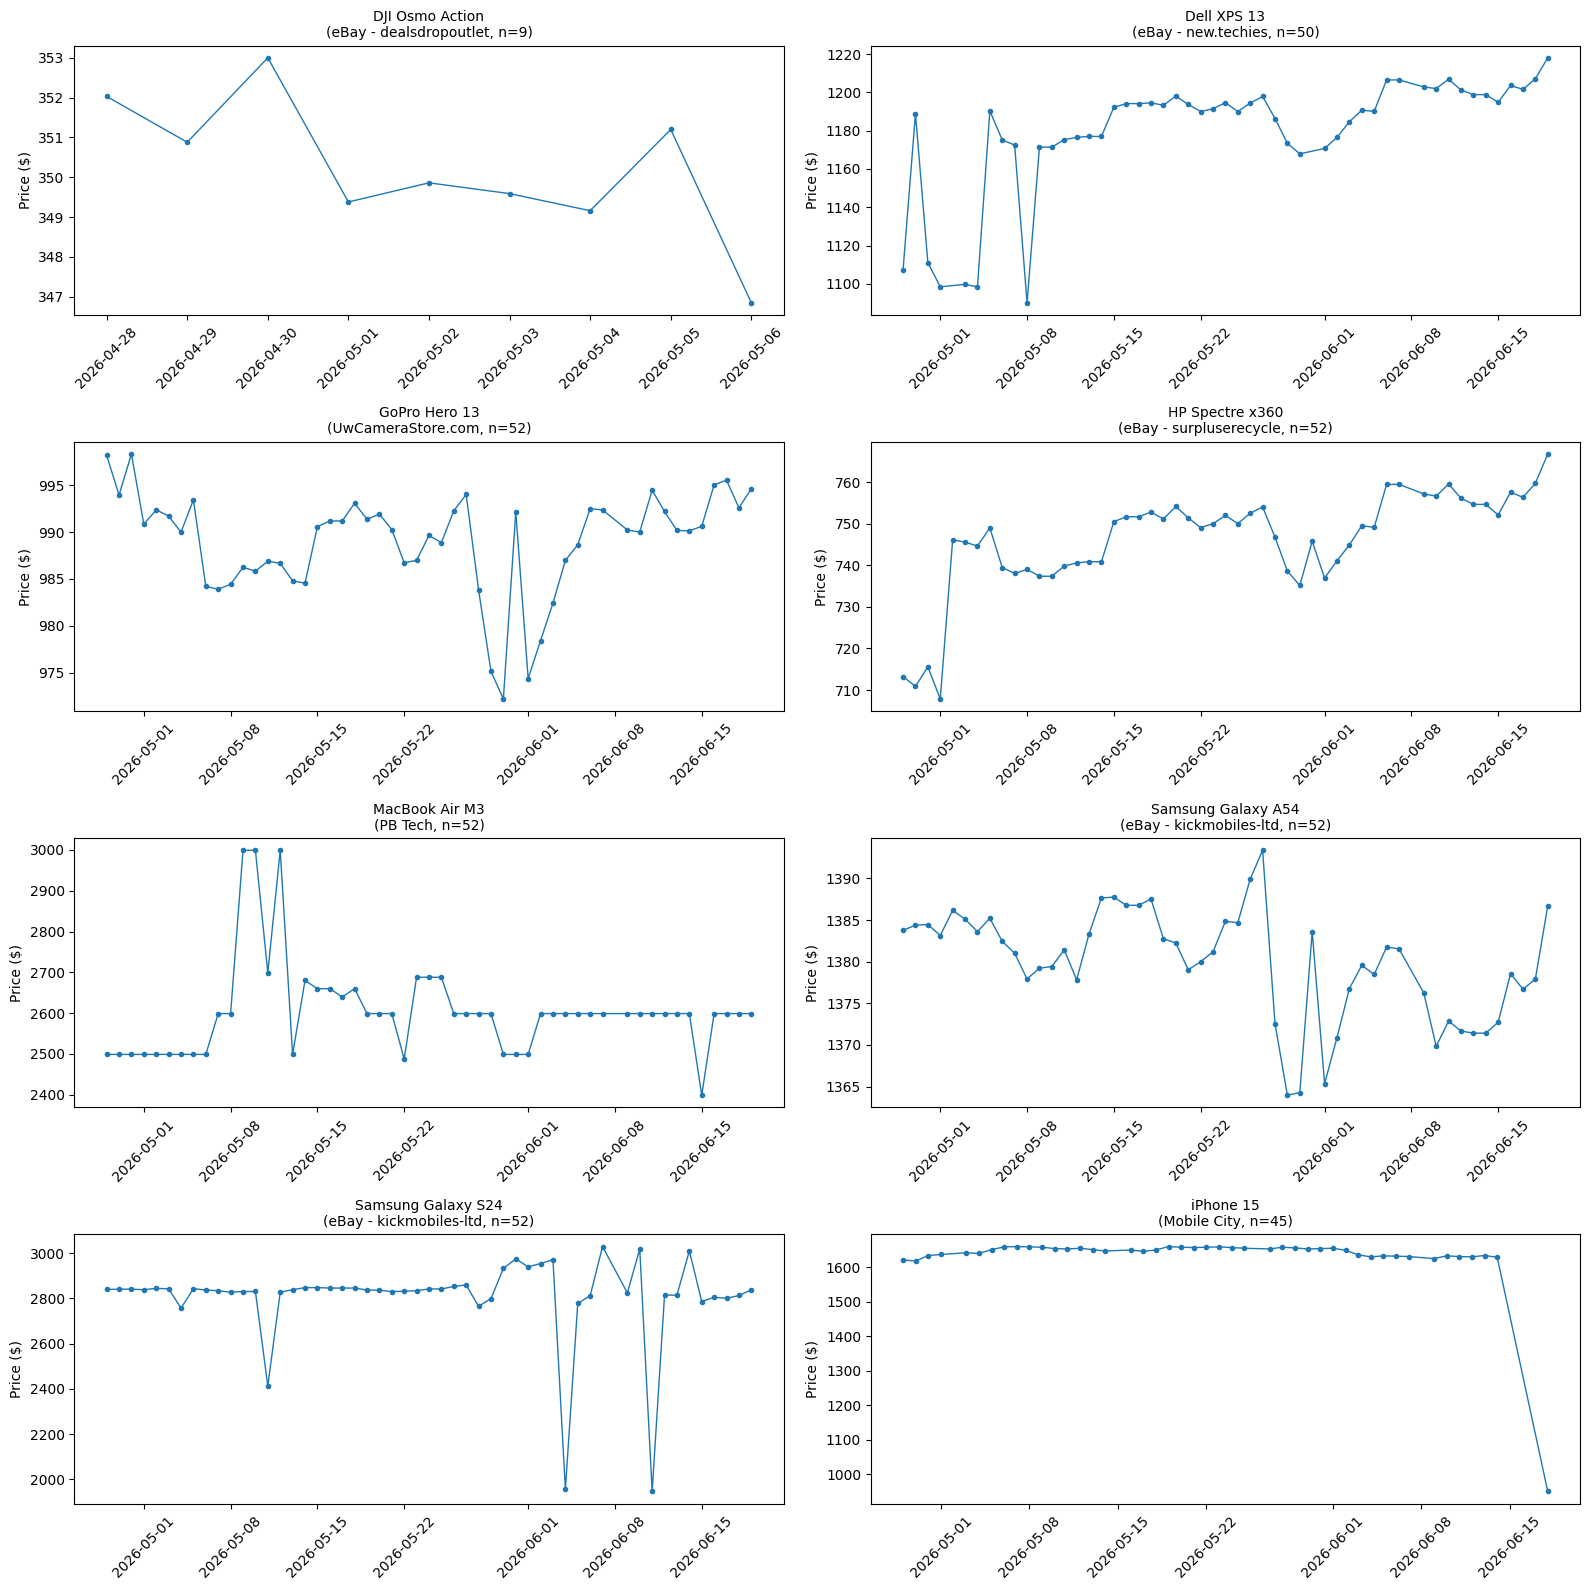

In [33]:
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

for i, row in top_seller_per_product.iterrows():
    product, seller = row['product_name'], row['seller']
    subset = df[(df['product_name'] == product) & (df['seller'] == seller)].sort_values('ds')
    
    ax = axes[i]
    ax.plot(subset['ds'], subset['y'], marker='o', markersize=3, linewidth=1)
    ax.set_title(f"{product}\n({seller}, n={len(subset)})", fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel("Price ($)")

plt.tight_layout()
plt.show()

## 5h. Data Quality Investigation Summary

What started as a routine check of price outliers (Section 5) uncovered four 
distinct, compounding data quality issues. Each was traced to root cause, 
fixed at the appropriate layer (staging vs. ML mart), and verified before 
moving to the next. This section consolidates the full investigation.

---

### Issue 1: `is_on_sale` mislabeling price increases as discounts

**Symptom:** 35 rows flagged `is_on_sale = 1` despite negative `discount_pct` 
(price *higher* than `old_price`).

**Root cause:** `old_price` is a frozen reference value per seller (often an 
MSRP/"was" price that rarely updates), while `price` fluctuates daily. When 
`price` drifted above the stale `old_price`, the discount math went negative 
but the flag still fired.

**Fix:** `mart_ml.sql` — `is_on_sale` now requires `discount_pct > 0`, not 
just `discount_pct IS NOT NULL`.

**Impact:** 397 → 361 correctly-flagged sale events.

---

### Issue 2: Product title contamination

**Symptom:** Extreme price outliers (Dell XPS 13 up to $7,494; DJI Osmo Action 
mixed with newer generations) that didn't match known retail prices for 
those products.

**Root cause:** Product normalization in `stg_electronic_products.sql` 
matched against `product_name` — the SerpAPI *search query* — not `title`, 
the actual listing name. Google Shopping's "related products" matching 
returned different generations, different product lines, and even different 
brands under the same search query (e.g. searching "DJI Osmo Action" returned 
"Osmo Action 5 Pro," "Osmo 360," "Osmo Pocket 3"; searching "Samsung Galaxy 
A54" returned OPPO A54).

**Also surfaced:** A subset of outliers were explained, not contamination — 
**Desertcart** (multiple regional domains) and **Ubuy** are cross-border 
import resellers whose prices legitimately include customs duties, import 
tax, and cross-border logistics markup on top of source price. Confirmed via 
their own public documentation. These are real prices, just not representative 
of local retail trends, and were excluded from seller-level modeling on that 
basis (not as a data error).

**Fix:** Rewrote the `normalized` CTE in `stg_electronic_products.sql` to 
validate against `title`, with explicit exclusion patterns per product for 
known contaminants (wrong generation, wrong product line, wrong brand, 
higher/lower SKU tier e.g. Pro/Plus/Ultra). Rows with no confident match are 
dropped rather than mislabeled.

**Impact:** `fact_price_snapshot` 14,094 → 9,452 rows (-33%). Verified clean 
via a product-specific pattern audit (0 genuine mismatches remaining). 
Permanent `accepted_values` dbt test added on `product_name` to prevent 
regression.

---

### Issue 3: Refurbished/used listings leaking through

**Symptom:** After fixing title contamination, trend charts for iPhone 15 
still showed implausible volatility — prices swinging between ~`$870` and 
~`$1,250` with no clear pattern.

**Root cause:** The existing `second_hand_condition` field (intended to flag 
used/refurbished stock per the pipeline's stated "new retail prices only" 
design) was not reliably populated by SerpAPI for all sellers. Condition 
information was present in the listing `title` instead (e.g. *"iPhone 15 128GB 
Pink Refurbished Excellent Grade"*) but going undetected.

**Fix:** Added `is_used_or_refurb_title` to `stg_electronic_products.sql` — 
a keyword-based check against `title` (refurbished, a/b grade, like new, 
open box, renewed, pre-owned, used) as a second line of defense alongside the 
structured field. Rows matching either signal are excluded.

**Impact:** 2,056 occurrences removed across the dataset (~22% of the 
then-current row count). iPhone 15 alone lost 1,239 rows — over half its 
volume came from refurbished stock.

---

### Issue 4: Multiple same-day listings collapsed into noisy series

**Symptom:** Even after Issues 1–3 were fixed, several product/seller time 
series still showed a dense day-to-day zigzag with no visible trend — 
inconsistent with how Prophet/ARIMA expect a price series to behave.

**Root cause:** `fact_price_snapshot` has one row per *listing*, and sellers 
routinely list multiple legitimate variants of the same product on the same 
day (storage size, color, bundle/accessory configuration). `mart_ml`'s lag 
and rolling-average window functions were treating each variant swap as if 
it were a real price change.

**Three aggregation strategies were tried, in order, each one informed by a 
genuine failure case found in the data:**

1. **Average across same-day variants** — worked when variant prices were 
   close together (e.g. 128GB vs 256GB storage tiers), but produced 
   meaningless numbers when variants diverged sharply — e.g. a GoPro Hero 13 
   standard bundle (~`$990`) averaged with a 2x-extra-battery bundle (~`$1,977`) 
   produced ~`$1,480`, a price matching no real listing.

2. **Cheapest same-day listing, then cheapest-with-reviews** — fixed the 
   GoPro case (the bundle's higher price no longer pollutes the series) and 
   correctly distinguished a legitimate cheaper color variant (reviews=55,000) 
   from a same-day zero-review "ghost" listing at a suspiciously round price. 
   But it failed when two listings shared *identical* rating/review metadata 
   while differing sharply in price, with no other field available to 
   distinguish them (e.g. iPhone 15 "128GB" at `$1,150` vs `$1,649`, same seller, 
   same day, same rating, same reviews).

3. **Closest to the seller's most-frequent price (final approach)** — for 
   each product/seller pair, prices are rounded to the nearest $10 bucket and 
   the most commonly-occurring bucket across the full tracked period is 
   identified as that seller's "typical" price. Each day's listing closest to 
   that typical price is kept. This is robust to all prior failure cases 
   without needing to know *why* a listing is priced differently — it simply 
   favors what a seller persistently charges over occasional outliers.

**Acknowledged tradeoff:** this approach will also smooth over genuine 
rare lower prices (e.g. a real, reviewed listing that happened to be 
unusually cheap for 2 days out of 52) in favor of the seller's typical price. 
For a forecasting use case, this is the right tradeoff — the goal is modeling 
the standard price trend, not capturing every promotional blip — but it's a 
deliberate simplification, not a perfect reconstruction of every listing's 
context.

**Impact:** Verified against the two known failure cases (GoPro bundle 
divergence, iPhone ghost-listing/identical-metadata cases) — both resolved 
cleanly. Final `mart_ml` row count: 3,552 (one row per product/seller/day, 
down from 14,094 listing-level rows originally).

---

### Net result

| Stage | Row count | Change |
|---|---|---|
| Original (unfixed) | 14,094 | — |
| After title-matching fix | 9,452 | -33% |
| After refurb/Pro-Max exclusion | 4,340 | -54% (cumulative) |
| After variant aggregation (final) | 3,552 | -75% (cumulative) |

Every row removed was either contamination, mislabeled data, or excluded by 
deliberate, documented business logic — not data lost to a careless filter. 
The reduction reflects how much noise was present in the raw scraped data, 
not a loss of useful signal.

### Permanent safeguards added

- `accepted_values` dbt test on `product_name` in `stg_electronic_products` 
  (catches future title-matching regressions)
- `not_null` test on `title` in `stg_electronic_products`
- `is_used_or_refurb_title` and `is_price_too_high`/`is_price_too_low` 
  retained as visible audit columns, not silently dropped
- `variant_count` retained in `mart_ml` as a diagnostic — flags days where 
  multiple listings existed and a selection had to be made

## 6a. Final Trend Verification

Plotted each product's top Tier 1 seller on the fully cleaned dataset. 
6 of 7 products (excluding DJI Osmo Action, which has no Tier 1 coverage) 
show clean, trend-like series consistent with genuine retail pricing behavior.

Two patterns investigated and confirmed acceptable:
- **Samsung Galaxy S24**: 3 isolated single-day drops out of 52 observations 
  — sporadic, not structural. Acceptable noise level for Prophet.
- **MacBook Air M3**: Apparent "jagged plateau" pattern confirmed as genuine 
  step-changes in typical price over time (seller manages 3-6 simultaneous 
  variants daily; the most-frequent-price aggregation is correctly tracking 
  a shifting price point, not malfunctioning).

**Conclusion:** Data cleaning phase complete. Dataset is ready for feature 
engineering. DJI Osmo Action excluded from initial modeling round due to 
insufficient current retail listings (55 total rows after cleaning).